# Check microscope magnification with grid

Check the magnification of a microscope by placing a grid sample (5 micrometers pitch) on the stage, applying widefield illumination and replacing the SPAD array detector by a large camera to image the grid.

## Import libraries

In [8]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.ndimage import gaussian_filter

## Custom functions for fitting a grid

To extract the magnification of the system, we fit a function describing a square grid to the image. The fitted pitch of the grid in pixels can be converted to a pitch *P_i* in micrometers since the camera pixel size is known (5.2 µm). Since the real pitch *P_r* is 5 µm, the magnification *M* is the ratio *P_i/P_r*.

In [2]:
def bin_image(image, binning=1, mode="mean", crop=True):
    """
    Downsample image by integer binning.

    Parameters
    ----------
    image : 2D ndarray
        Input image.
    binning : int
        Binning factor. 1 means no binning.
    mode : {"mean", "sum"}
        How to combine pixels inside each bin.
    crop : bool
        If True, crop image edges so shape is divisible by `binning`.
        If False, raises ValueError when shape is not divisible.

    Returns
    -------
    binned : 2D ndarray
        Binned image.
    """
    if binning < 1 or int(binning) != binning:
        raise ValueError("binning must be a positive integer")
    binning = int(binning)

    if binning == 1:
        return image.copy()

    ny, nx = image.shape
    ny2 = (ny // binning) * binning
    nx2 = (nx // binning) * binning

    if (ny2 != ny or nx2 != nx) and not crop:
        raise ValueError("image shape must be divisible by binning when crop=False")

    image_c = image[:ny2, :nx2]
    reshaped = image_c.reshape(ny2 // binning, binning, nx2 // binning, binning)

    if mode == "mean":
        return reshaped.mean(axis=(1, 3))
    elif mode == "sum":
        return reshaped.sum(axis=(1, 3))
    else:
        raise ValueError("mode must be 'mean' or 'sum'")

def nearest_line_distance(t, pitch):
    return pitch * np.abs((t / pitch + 0.5) % 1.0 - 0.5)

def grid_model(params, x, y, square=True, with_gradient=True, with_blur=True):
    if square:
        if with_gradient and with_blur:
            x0, y0, theta, pitch, line_width, amp, bg, gx, gy, sx, sy, blur_sigma = params
        elif with_gradient and not with_blur:
            x0, y0, theta, pitch, line_width, amp, bg, gx, gy, sx, sy = params
            blur_sigma = 0.0
        elif (not with_gradient) and with_blur:
            x0, y0, theta, pitch, line_width, amp, bg, sx, sy, blur_sigma = params
            gx = 0.0
            gy = 0.0
        else:
            x0, y0, theta, pitch, line_width, amp, bg, sx, sy = params
            gx = 0.0
            gy = 0.0
            blur_sigma = 0.0

        pitch_x = pitch_y = pitch

    else:
        if with_gradient and with_blur:
            x0, y0, theta, pitch_x, pitch_y, line_width, amp, bg, gx, gy, sx, sy, blur_sigma = params
        elif with_gradient and not with_blur:
            x0, y0, theta, pitch_x, pitch_y, line_width, amp, bg, gx, gy, sx, sy = params
            blur_sigma = 0.0
        elif (not with_gradient) and with_blur:
            x0, y0, theta, pitch_x, pitch_y, line_width, amp, bg, sx, sy, blur_sigma = params
            gx = 0.0
            gy = 0.0
        else:
            x0, y0, theta, pitch_x, pitch_y, line_width, amp, bg, sx, sy = params
            gx = 0.0
            gy = 0.0
            blur_sigma = 0.0

    xr = x - x0
    yr = y - y0

    c = np.cos(theta)
    s = np.sin(theta)

    u = (c * xr + s * yr) / sx
    v = (-s * xr + c * yr) / sy

    du = nearest_line_distance(u, pitch_x)
    dv = nearest_line_distance(v, pitch_y)

    half_width = line_width / 2.0
    gu = (du <= half_width).astype(float)
    gv = (dv <= half_width).astype(float)

    g = np.maximum(gu, gv)

    xc = (x.shape[1] - 1) / 2.0
    yc = (y.shape[0] - 1) / 2.0
    background = bg + gx * (x - xc) + gy * (y - yc)

    model = background + amp * g
    model = gaussian_filter(model, sigma=blur_sigma, mode="nearest")
    
    return model

def residuals(params, image, x, y, square=True, with_gradient=True, with_blur=True):
    model = grid_model(params, x, y, square=square, with_gradient=with_gradient, with_blur=with_blur)
    return (model - image).ravel()

def scale_params_for_binning(p0, binning, square=True, with_gradient=True):
    """
    Convert an initial guess from original-pixel units to binned-image units.
    """
    p0 = np.asarray(p0, dtype=float).copy()
    b = float(binning)

    # x0, y0
    p0[0] /= b
    p0[1] /= b

    if square:
        # pitch, sigma
        p0[3] /= b
        p0[4] /= b
        if with_gradient:
            # gx, gy are intensity change per pixel -> per binned pixel
            p0[7] *= b
            p0[8] *= b
    else:
        # pitch_x, pitch_y, sigma
        p0[3] /= b
        p0[4] /= b
        p0[5] /= b
        if with_gradient:
            p0[8] *= b
            p0[9] *= b

    return p0

def unscale_params_from_binning(params, binning, square=True, with_gradient=True):
    """
    Convert fitted parameters from binned-image units back to original-pixel units.
    """
    params = np.asarray(params, dtype=float).copy()
    b = float(binning)

    params[0] *= b
    params[1] *= b

    if square:
        params[3] *= b
        params[4] *= b
        if with_gradient:
            params[7] /= b
            params[8] /= b
    else:
        params[3] *= b
        params[4] *= b
        params[5] *= b
        if with_gradient:
            params[8] /= b
            params[9] /= b

    return params

def fit_grid(
    image,
    p0,
    bounds=None,
    square=True,
    with_gradient=True,
    binning=1,
    binning_mode="mean",
    crop_for_binning=True,
    return_binned_image=False,
):
    """
    Fit grid model to image, with optional preprocessing by integer binning.

    Parameters
    ----------
    image : 2D ndarray
        Original image.
    p0 : sequence
        Initial guess in ORIGINAL image pixel units.
    bounds : tuple or None
        Bounds in the FIT space. If None, defaults are created for the binned image.
    square, with_gradient : bool
        Same as before.
    binning : int
        Integer binning factor. 1 means no binning.
    binning_mode : {"mean", "sum"}
        How to bin the image.
    crop_for_binning : bool
        Crop edges if needed to make size divisible by binning.
    return_binned_image : bool
        If True, also return the binned image used for the fit.

    Returns
    -------
    result : OptimizeResult
        Result, with result.x converted back to ORIGINAL image pixel units.
        Extra fields added:
            - x_binned
            - binning
            - image_shape_fit
            - image_shape_original
    """
    image_fit = bin_image(image, binning=binning, mode=binning_mode, crop=crop_for_binning)
    ny, nx = image_fit.shape
    y, x = np.mgrid[0:ny, 0:nx]

    p0_fit = scale_params_for_binning(p0, binning, square=square, with_gradient=with_gradient)

    if bounds is None:
        if square and with_gradient:
            lower = [-np.inf, -np.inf, -np.pi/2, 1, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
            upper = [np.inf, np.inf,  np.pi/2, max(nx, ny), np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]
        elif square and not with_gradient:
            lower = [0, 0, -np.pi/2, 1, 0.2, -np.inf, -np.inf, 0.5, 0.5]
            upper = [nx, ny,  np.pi/2, max(nx, ny), 20, np.inf, np.inf, 2.0, 2.0]
        elif (not square) and with_gradient:
            lower = [0, 0, -np.pi/2, 1, 1, 0.2, -np.inf, -np.inf, -np.inf, -np.inf, 0.5, 0.5]
            upper = [nx, ny,  np.pi/2, max(nx, ny), max(nx, ny), 20, np.inf, np.inf, np.inf, np.inf, 2.0, 2.0]
        else:
            lower = [0, 0, -np.pi/2, 1, 1, 0.2, -np.inf, -np.inf, 0.5, 0.5]
            upper = [nx, ny,  np.pi/2, max(nx, ny), max(nx, ny), 20, np.inf, np.inf, 2.0, 2.0]
        bounds = (lower, upper)

    result = least_squares(
        residuals,
        x0=np.asarray(p0_fit, dtype=float),
        bounds=bounds,
        args=(image_fit, x, y, square, with_gradient),
        method="trf",
        loss="soft_l1",
        gtol=1e-15,
        ftol=1e-15,
        xtol=1e-15,
        max_nfev=20000,
    )

    result.x_binned = result.x.copy()
    result.x = unscale_params_from_binning(result.x, binning, square=square, with_gradient=with_gradient)
    result.binning = int(binning)
    result.image_shape_fit = image_fit.shape
    result.image_shape_original = image.shape

    if return_binned_image:
        return result, image_fit
    return result

def render_fitted_grid(
    image,
    fit_params,
    square=True,
    with_gradient=True,
    out_path=None,
    show=True,
    overlay=True,
    contour_level=0.5,
    binning=1,
    binning_mode="mean",
    crop_for_binning=True,
    params_are_in_original_pixels=True,
):
    """
    Render fitted grid, optionally on a binned version of the image,
    and add a color bar to each image panel.
    """
    image_show = bin_image(image, binning=binning, mode=binning_mode, crop=crop_for_binning)
    ny, nx = image_show.shape
    y, x = np.mgrid[0:ny, 0:nx]

    fit_params = np.asarray(fit_params, dtype=float)
    if binning > 1 and params_are_in_original_pixels:
        fit_params_render = scale_params_for_binning(
            fit_params, binning, square=square, with_gradient=with_gradient
        )
    else:
        fit_params_render = fit_params

    fit_img = grid_model(fit_params_render, x, y, square=square, with_gradient=with_gradient)

    if overlay:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes = np.atleast_1d(axes)

    im0 = axes[0].imshow(image_show, cmap="gray", origin="upper")
    axes[0].set_title(f"Image (binning={binning})")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(fit_img, cmap="gray", origin="upper")
    axes[1].set_title("Fitted grid")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    if overlay:
        fit_norm = fit_img - fit_img.min()
        if fit_norm.max() > 0:
            fit_norm = fit_norm / fit_norm.max()

        im2 = axes[2].imshow(image_show, cmap="gray", origin="upper")
        axes[2].contour(fit_norm, levels=[contour_level], linewidths=1)
        axes[2].set_title("Overlay")
        axes[2].axis("off")
        fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fit_img

def objective(params, image, x, y, square=True, with_gradient=True, with_blur=True):
    model = grid_model(params, x, y, square=square, with_gradient=with_gradient, with_blur=with_blur)
    return np.mean((model - image) ** 2)

def overlay_fitted_grid_contours(
    image,
    fit_params=None,
    out_path=None,
    show=True,
    color="r",
    linewidth=1.0,
    cmap="gray",
):
    """
    Draw the original image with fitted grid contour lines overlaid.

    Assumes a square grid with sharp edges and no blur.
    Parameter order:
        [x0, y0, theta, pitch, line_width, amplitude, background, gx, gy, sx, sy]

    The contour is drawn from the ideal binary grid mask only.

    Parameters
    ----------
    image : 2D ndarray
        Original grayscale image.
    fit_params : sequence
        Fitted parameters in original image pixel units.
    out_path : str or None
        Optional path to save the overlay figure.
    show : bool
        If True, display the figure.
    color : str
        Contour color.
    linewidth : float
        Contour line width.

    Returns
    -------
    grid_mask : 2D ndarray
        Binary mask of the fitted sharp grid.
    """
    ny, nx = image.shape
    y, x = np.mgrid[0:ny, 0:nx]
    
    if fit_params is not None:
        x0, y0, theta, pitch, line_width, amp, bg, gx, gy, sx, sy, blur = fit_params

        # Shift image coordinates
        xr = x - x0
        yr = y - y0
    
        # Rotate into grid coordinates
        c = np.cos(theta)
        s = np.sin(theta)
    
        u = (c * xr + s * yr) / sx
        v = (-s * xr + c * yr) / sy
    
        # Distance to nearest vertical / horizontal line
        def nearest_line_distance(t, pitch):
            return pitch * np.abs((t / pitch + 0.5) % 1.0 - 0.5)
    
        du = nearest_line_distance(u, pitch)
        dv = nearest_line_distance(v, pitch)

        half_width = line_width / 2.0
    
        # Sharp binary grid
        gu = (du <= half_width).astype(float)
        gv = (dv <= half_width).astype(float)
        grid_mask = np.maximum(gu, gv)

    # Plot overlay
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image, cmap=cmap, origin="upper")
    if fit_params is not None:
        ax.contour(grid_mask, levels=[0.5], colors=color, linewidths=linewidth)
    ax.axis("off")
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")

    if fit_params is not None:
        return grid_mask

## File

The file contains a video of 100 frames of the same grid image. We fit the magnification for each frame to get an average and standard deviation.

In [3]:
folder = r"Y:\Data MMS server\Protocol\Magnification\With_Thorcam_Grid_5um"
file = '0_4.tif' # 100 x 1024 x 1280

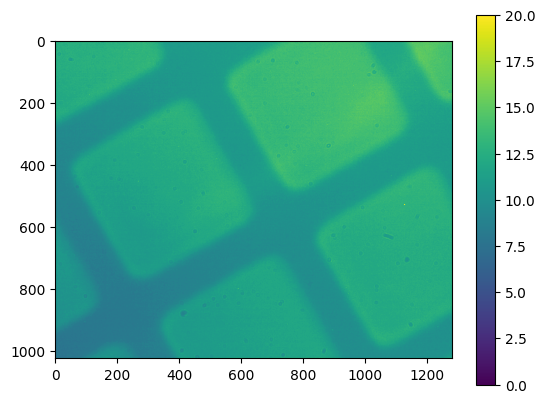

In [4]:
image = tifffile.imread(folder + "\\" + file)
plt.figure()
plt.imshow(image[0], vmin=0, vmax=20)
plt.colorbar()

Fit procedure:
* Invert and rescale the intensity values of each frame, so that the background becomes 0 and the grid has the maximum intensity value
* Make the image 4x smaller in each dimension to speed up the fit
* Use differential_evolution to fit the grid
* Print the magnification

In [72]:
fitresults = np.zeros((100,12))
binning = 4

for i in range(100):
    image_binned = bin_image(-1*image[i]+np.max(image[i]), binning=binning)
    ny, nx = image_binned.shape
    y, x = np.mgrid[0:ny, 0:nx]
    
    bounds = [
        (0, nx),                        # x position offset
        (0, ny),                        # y position offset
        (-np.pi/4, np.pi/4),            # theta
        (400/binning, 700/binning),     # pitch
        (50/binning, 250/binning),      # line_width
        (0, 2 * image_binned.max()),    # amplitude
        (image_binned.min(), image_binned.max()),  # background
        (-0.3, 0.3),                    # intensity gradient in x direction
        (-0.3, 0.3),                    # intensity gradient in y direction
        (0.99, 1.01),                   # stretch factor in x direction
        (0.99, 1.01),                   # stretch factor in y direction
        (0.0, 5.0/binning),             # blur_sigma
    ]
    
    res = differential_evolution(
        objective,
        bounds=bounds,
        args=(image_binned, x, y),
        #popsize=15,
        tol=1e-3,
        #polish=False,
        #workers=-1,
        #updating="deferred"
    )
    print(res.x[3]*binning*5.2/5)
    fitresults[i] = res.x

601.381621093346
600.326766748277
595.8521464991791
600.0939058861402
601.664901840692
600.3765695132923
601.7123330940997
602.704325376513
597.1049266206071
601.0678775647474
596.0934429330675
602.1844962214727
597.7203666334781
600.1455859500354
598.4179663553844
598.1576953265995
597.0967472194369
602.240003899091
602.1338416535857
595.2310398130675
598.4212837452303
596.715255554425
595.9358490577242
599.44412566277
602.4903940519914
603.2931511196027
601.1310453040466
600.810915711039
596.1357537669026
602.8236197092657
596.0503122308145
598.1970234603393
601.9453927639494
600.3395057716364
601.7199472013662
598.3120469687027
596.0096021067158
603.3584407721653
598.6199531539357
594.9724044790166
599.4815689164384
596.4475334886614
596.883564710911
598.8825182575213
602.656100570113
599.4867049850899
596.1753072949008
600.218107343681
599.2687089015212
600.4680442630255
599.0747737348206
599.4914860285287
594.8885103959362
596.3024399389078
602.0631357793652
601.3707583931161
601.

Value 3 of the fitresults array is the grid pitch in px for the binned image. The magnifcation is M = binning * 5.2 / 5

In [76]:
np.mean(fitresults, axis=0)*binning*5.2/5

array([ 6.76280292e+02,  5.73786431e+02, -2.14903434e+00,  5.99221049e+02,
        1.28433863e+02,  8.99232589e+00,  3.07555289e+02, -2.88246010e-02,
        4.45320400e-02,  4.15124830e+00,  4.17307638e+00,  5.19995323e+00])

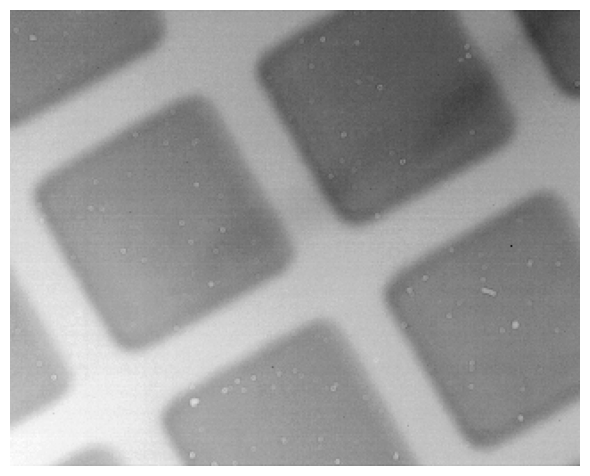

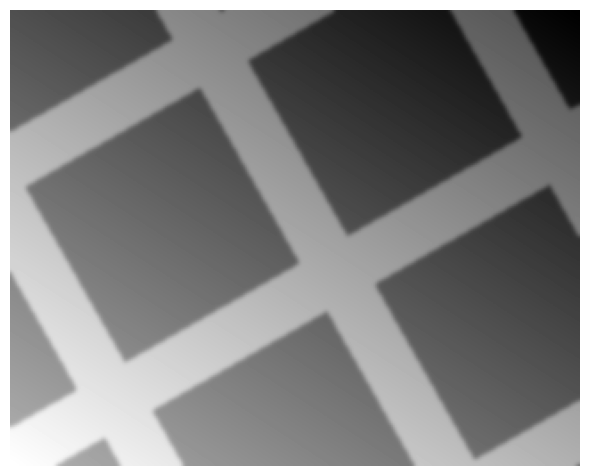

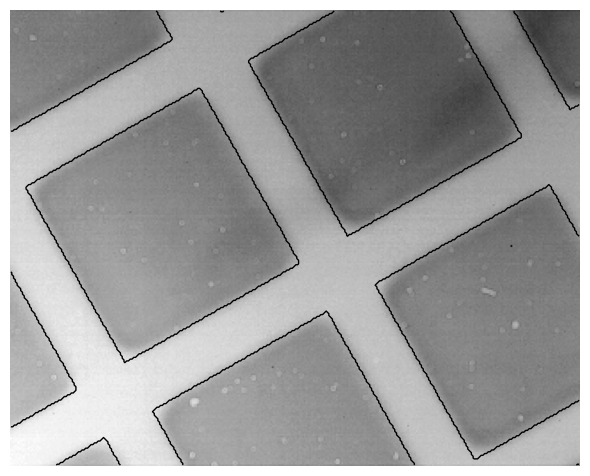

In [71]:
_ = overlay_fitted_grid_contours(image_binned, None, cmap='gray', color='k', out_path='original.png')
_ = overlay_fitted_grid_contours(grid_model(res.x, x, y), None, cmap='gray', color='k', out_path='fit.png')
_ = overlay_fitted_grid_contours(image_binned, res.x, cmap='gray', color='k', out_path='overlay.png')